In [1]:
# ============================================================
# CELL 1 - Imports and Parameters
# ============================================================
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.signal import savgol_filter

INPUT_REMAPPED_CSV = Path(r"C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\11\segments\part2\traj_sidewalk_remapped.csv")
INPUT_LANE_CSV = Path(r"C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\11\segments\part2\traj_lane.csv")
INPUT_METRICS_CSV = Path(str(INPUT_REMAPPED_CSV).replace('_sidewalk_remapped.csv', '_station_side_metrics.csv'))

BIN_SIZE = 0.08
N_BINS = 192
MIN_PTS_PER_BIN = 3
SG_WINDOW = 11 
SG_POLY = 4
DROP_ZERO_VALID = True
PROFILE_CROP_MODE = "full_profile"  # "full_profile" or "edge_window"
EDGE_BUFFER_M = 1
REZERO_PROFILE_AT_CROP_START = True
TARGET_LABELS = ["RAMP", "CURB_NO_RAMP", "DEPRESSED_DITCH"]
PLOT_SAMPLES_PER_CLASS = 3
RANDOM_SEED = 0

PROFILE_MAX_V = N_BINS * BIN_SIZE
OUTPUT_CSV = INPUT_REMAPPED_CSV.with_name("cnn_dataset.csv")
PROFILE_COLS = [f"z_{i:03d}" for i in range(N_BINS)]
GAP_COLS = [f"gap_{i:03d}" for i in range(N_BINS)]
PAD_COLS = [f"pad_{i:03d}" for i in range(N_BINS)]
REQ_SW_COLS = ["z", "s_m", "v_m", "side", "label", "class"]
REQ_LANE_COLS = ["z", "s_m", "v_m", "side"]
REQ_METRIC_COLS = ["s_m", "side", "kink_dz", "kink_slope", "lane_edge_v", "side_edge_v"]

print(f"Input remapped CSV: {INPUT_REMAPPED_CSV}")
print(f"Input lane CSV    : {INPUT_LANE_CSV}")
print(f"Input metrics CSV : {INPUT_METRICS_CSV}")
print(f"Output CSV        : {OUTPUT_CSV}")
print(f"Target labels     : {TARGET_LABELS}")
print(f"Profile span      : 0.00 to {PROFILE_MAX_V:.2f} m with {N_BINS} bins @ {BIN_SIZE:.2f} m")
print(f"Profile crop mode : {PROFILE_CROP_MODE} | edge buffer={EDGE_BUFFER_M:.2f} m | rezero={REZERO_PROFILE_AT_CROP_START}")


Input remapped CSV: C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\11\segments\part2\traj_sidewalk_remapped.csv
Input lane CSV    : C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\11\segments\part2\traj_lane.csv
Input metrics CSV : C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\11\segments\part2\traj_station_side_metrics.csv
Output CSV        : C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\11\segments\part2\cnn_dataset.csv
Target labels     : ['RAMP', 'CURB_NO_RAMP', 'DEPRESSED_DITCH']
Profile span      : 0.00 to 15.36 m with 192 bins @ 0.08 m
Profile crop mode : full_profile | edge buffer=1.00 m | rezero=True


In [2]:
# ============================================================
# CELL 2 - Load and Validate CSV Inputs
# ============================================================
df_sw = pd.read_csv(INPUT_REMAPPED_CSV)
missing_sw = [c for c in REQ_SW_COLS if c not in df_sw.columns]
if missing_sw:
    raise ValueError(f"Missing required sidewalk columns: {missing_sw}")

df_lane = pd.read_csv(INPUT_LANE_CSV)
missing_lane = [c for c in REQ_LANE_COLS if c not in df_lane.columns]
if missing_lane:
    raise ValueError(f"Missing required lane columns: {missing_lane}")

df_metrics = pd.read_csv(INPUT_METRICS_CSV)
missing_metrics = [c for c in REQ_METRIC_COLS if c not in df_metrics.columns]
if missing_metrics:
    raise ValueError(f"Missing required metrics columns: {missing_metrics}")

df_sw = df_sw.copy()
df_sw["side"] = df_sw["side"].astype(str).str.strip().str.upper()
df_sw["label"] = df_sw["label"].astype(str).str.strip()
df_sw["class"] = pd.to_numeric(df_sw["class"], errors="coerce").astype("Int64")
df_sw["_s_key"] = pd.to_numeric(df_sw["s_m"], errors="coerce").round(3)

df_lane = df_lane.copy()
df_lane["side"] = df_lane["side"].astype(str).str.strip().str.upper()
df_lane["_s_key"] = pd.to_numeric(df_lane["s_m"], errors="coerce").round(3)

df_metrics = df_metrics.copy()
df_metrics["side"] = df_metrics["side"].astype(str).str.strip().str.upper()
df_metrics["_s_key"] = pd.to_numeric(df_metrics["s_m"], errors="coerce").round(3)
# Use absolute kink metrics so opposite signs do not cancel out in downstream stats/features.
df_metrics["kink_dz"] = pd.to_numeric(df_metrics["kink_dz"], errors="coerce").abs()
df_metrics["kink_slope"] = pd.to_numeric(df_metrics["kink_slope"], errors="coerce").abs()
for edge_col in ["lane_edge_v", "side_edge_v", "interface_center_v"]:
    if edge_col in df_metrics.columns:
        df_metrics[edge_col] = pd.to_numeric(df_metrics[edge_col], errors="coerce")
df_metrics = df_metrics.drop_duplicates(subset=["_s_key", "side"], keep="last")

print(f"Sidewalk rows loaded: {len(df_sw):,}")
print(f"Lane rows loaded    : {len(df_lane):,}")
print(f"Metrics rows loaded : {len(df_metrics):,}")
print("Unique labels      :", sorted(df_sw["label"].dropna().unique().tolist()))
print("Unique classes     :", sorted(df_sw["class"].dropna().astype(int).unique().tolist()))

lane_group_sizes = df_lane.groupby(["_s_key", "side"]).size()
print(f"Lane station-side groups: {len(lane_group_sizes):,}")

df_sw[REQ_SW_COLS].head()


Sidewalk rows loaded: 507,235
Lane rows loaded    : 927,489
Metrics rows loaded : 814
Unique labels      : ['CURB_NO_RAMP', 'DEPRESSED_DITCH', 'NO_SIDEWALK', 'RAMP', 'SEPARATED_NO_RAMP', 'UNKNOWN']
Unique classes     : [0, 1, 2, 3, 4, 5]
Lane station-side groups: 780


,z,s_m,v_m,side,label,class
0,668.29333,0.0,12.6156,RIGHT,UNKNOWN,5
1,668.30033,0.0,12.6158,RIGHT,UNKNOWN,5
2,668.29533,0.0,12.6374,RIGHT,UNKNOWN,5
3,668.30233,0.0,12.6423,RIGHT,UNKNOWN,5
4,668.30333,0.0,12.6528,RIGHT,UNKNOWN,5


In [3]:
# ============================================================
# CELL 3 - Helper Functions
# ============================================================
CLASS_NAME_TO_INT = {
    "RAMP": 0,
    "CURB_NO_RAMP": 1,
    "SEPARATED_NO_RAMP": 2,
    "NO_SIDEWALK": 3,
    "DEPRESSED_DITCH": 4,
    "UNKNOWN": 5,
}

def mode_or_first(series):
    s = series.dropna()
    if s.empty:
        return None
    m = s.mode()
    return m.iloc[0] if not m.empty else s.iloc[0]

def prepare_profile_arrays(v, z):
    v = np.asarray(v, dtype=float)
    z = np.asarray(z, dtype=float)
    keep = np.isfinite(v) & np.isfinite(z)
    v = np.abs(v[keep])
    z = z[keep]
    return v, z

def bin_profile(v, z, bin_size=BIN_SIZE, n_bins=N_BINS, min_pts_per_bin=MIN_PTS_PER_BIN):
    v, z = prepare_profile_arrays(v, z)
    keep = (v >= 0.0) & (v < n_bins * bin_size)
    v = v[keep]
    z = z[keep]

    z_bins = np.full(n_bins, np.nan, dtype=float)
    mask = np.zeros(n_bins, dtype=np.uint8)
    counts = np.zeros(n_bins, dtype=int)

    if len(v) == 0:
        return z_bins, mask, counts

    bin_idx = np.floor(v / bin_size).astype(int)
    bin_idx = np.clip(bin_idx, 0, n_bins - 1)

    for i in range(n_bins):
        sel = bin_idx == i
        c = int(sel.sum())
        counts[i] = c
        if c >= min_pts_per_bin:
            z_bins[i] = float(np.median(z[sel]))
            mask[i] = 1

    return z_bins, mask, counts

def interpolate_internal_nans(z_bins, mask):
    z_out = np.array(z_bins, dtype=float, copy=True)
    gap_flag = np.zeros_like(mask, dtype=np.uint8)
    pad_flag = np.zeros_like(mask, dtype=np.uint8)
    valid_idx = np.flatnonzero(mask == 1)
    if len(valid_idx) == 0:
        pad_flag[:] = 1
        return np.zeros_like(z_out), -1, gap_flag, pad_flag

    last_valid_bin = int(valid_idx[-1])
    pad_flag[last_valid_bin + 1 :] = 1

    if len(valid_idx) == 1:
        z_out[: last_valid_bin + 1] = 0.0
        z_out[last_valid_bin] = float(z_bins[last_valid_bin])
        z_out[last_valid_bin + 1 :] = 0.0
        return z_out, last_valid_bin, gap_flag, pad_flag

    x = np.arange(last_valid_bin + 1, dtype=float)
    z_out[: last_valid_bin + 1] = np.interp(x, valid_idx.astype(float), z_bins[valid_idx])
    gap_flag[: last_valid_bin + 1] = ((mask[: last_valid_bin + 1] == 0)).astype(np.uint8)
    z_out[last_valid_bin + 1 :] = 0.0
    return z_out, last_valid_bin, gap_flag, pad_flag

def smooth_until_last_valid(z_interp, last_valid_bin, sg_window=SG_WINDOW, sg_poly=SG_POLY):
    z_s = np.array(z_interp, dtype=float, copy=True)
    if last_valid_bin < 0:
        z_s[:] = 0.0
        return z_s

    valid_len = last_valid_bin + 1
    if valid_len >= sg_window and sg_window % 2 == 1 and sg_window > sg_poly:
        z_s[:valid_len] = savgol_filter(z_s[:valid_len], window_length=sg_window, polyorder=sg_poly, mode="interp")

    z_s[last_valid_bin + 1 :] = 0.0
    return z_s

lane_groups = {key: grp.copy() for key, grp in df_lane.groupby(["_s_key", "side"], sort=False)}
metric_lookup_cols = ["kink_dz", "kink_slope", "lane_edge_v", "side_edge_v"]
if "interface_center_v" in df_metrics.columns:
    metric_lookup_cols.append("interface_center_v")
metrics_lookup = df_metrics.set_index(["_s_key", "side"])[metric_lookup_cols].to_dict(orient="index")
print(f"Lane lookup keys cached   : {len(lane_groups):,}")
print(f"Metrics lookup keys cached: {len(metrics_lookup):,}")


Lane lookup keys cached   : 780
Metrics lookup keys cached: 814


In [4]:
# ============================================================
# CELL 4 - Build One Sample Per (s_m, side)
# ============================================================
def build_sample(group_df, source_file):
    label = mode_or_first(group_df["label"])
    class_mode = mode_or_first(group_df["class"])
    if class_mode is not None and pd.notna(class_mode):
        class_mode = int(class_mode)

    if label not in TARGET_LABELS:
        return None, "dropped_non_target"

    s_key = float(mode_or_first(group_df["_s_key"]))
    s_val = float(mode_or_first(group_df["s_m"]))
    side = str(mode_or_first(group_df["side"]))

    sw_v, sw_z = prepare_profile_arrays(group_df["v_m"].to_numpy(), group_df["z"].to_numpy())

    lane_df = lane_groups.get((s_key, side), None)
    metric_row = metrics_lookup.get((s_key, side), {})
    if lane_df is None:
        lane_v = np.array([], dtype=float)
        lane_z = np.array([], dtype=float)
    else:
        lane_v, lane_z = prepare_profile_arrays(lane_df["v_m"].to_numpy(), lane_df["z"].to_numpy())

    if len(sw_v) == 0 and len(lane_v) == 0:
        return None, "dropped_zero_valid"

    v_all = np.concatenate([sw_v, lane_v]) if len(lane_v) > 0 else sw_v.copy()
    z_all = np.concatenate([sw_z, lane_z]) if len(lane_z) > 0 else sw_z.copy()

    crop_start_v = np.nan
    crop_end_v = np.nan
    crop_width_m = np.nan
    crop_applied = False
    lane_edge_v = metric_row.get("lane_edge_v", np.nan)
    side_edge_v = metric_row.get("side_edge_v", np.nan)
    interface_center_v = metric_row.get("interface_center_v", np.nan)

    if PROFILE_CROP_MODE == "edge_window":
        if pd.notna(lane_edge_v) and pd.notna(side_edge_v):
            lane_edge_abs = abs(float(lane_edge_v))
            side_edge_abs = abs(float(side_edge_v))
            crop_start_v = min(lane_edge_abs, side_edge_abs)
            crop_end_v = max(lane_edge_abs, side_edge_abs) + float(EDGE_BUFFER_M)
            crop_width_m = crop_end_v - crop_start_v

            keep_crop = (v_all >= crop_start_v) & (v_all <= crop_end_v)
            if np.any(keep_crop):
                v_all = v_all[keep_crop]
                z_all = z_all[keep_crop]
                crop_applied = True
                if REZERO_PROFILE_AT_CROP_START:
                    v_all = v_all - crop_start_v
        else:
            crop_width_m = np.nan
    elif PROFILE_CROP_MODE != "full_profile":
        raise ValueError(f"Unknown PROFILE_CROP_MODE={PROFILE_CROP_MODE!r}. Expected 'full_profile' or 'edge_window'.")

    z_bins, mask, counts = bin_profile(v_all, z_all)
    z_interp, last_valid_bin, gap_flag, pad_flag = interpolate_internal_nans(z_bins, mask)
    n_valid_bins = int(mask.sum())

    if DROP_ZERO_VALID and n_valid_bins == 0:
        return None, "dropped_zero_valid"

    z_s = smooth_until_last_valid(z_interp, last_valid_bin)

    row = {f"z_{i:03d}": float(z_s[i]) for i in range(N_BINS)}
    row.update({f"gap_{i:03d}": int(gap_flag[i]) for i in range(N_BINS)})
    row.update({f"pad_{i:03d}": int(pad_flag[i]) for i in range(N_BINS)})
    row.update({
        "label": label,
        "class_int": class_mode,
        "feat_kink_dz": float(metric_row.get("kink_dz", np.nan)) if pd.notna(metric_row.get("kink_dz", np.nan)) else np.nan,
        "feat_kink_slope": float(metric_row.get("kink_slope", np.nan)) if pd.notna(metric_row.get("kink_slope", np.nan)) else np.nan,
        "profile_crop_mode": PROFILE_CROP_MODE,
        "edge_buffer_m": float(EDGE_BUFFER_M),
        "crop_applied": int(crop_applied),
        "crop_start_v": float(crop_start_v) if pd.notna(crop_start_v) else np.nan,
        "crop_end_v": float(crop_end_v) if pd.notna(crop_end_v) else np.nan,
        "crop_width_m": float(crop_width_m) if pd.notna(crop_width_m) else np.nan,
        "lane_edge_v": float(lane_edge_v) if pd.notna(lane_edge_v) else np.nan,
        "side_edge_v": float(side_edge_v) if pd.notna(side_edge_v) else np.nan,
        "interface_center_v": float(interface_center_v) if pd.notna(interface_center_v) else np.nan,
        "s_m": s_val,
        "side": side,
        "source_file": source_file,
        "n_valid_bins": n_valid_bins,
        "last_valid_bin": int(last_valid_bin),
        "n_sidewalk_pts": int(len(sw_v)),
        "n_lane_pts": int(len(lane_v)),
    })
    return row, "kept"

samples = []
stats = {
    "total_groups": 0,
    "kept": 0,
    "dropped_non_target": 0,
    "dropped_zero_valid": 0,
}

grouped = df_sw.groupby(["_s_key", "side"], sort=True, dropna=False)
for (_, _), group_df in grouped:
    stats["total_groups"] += 1
    row, status = build_sample(group_df, str(INPUT_REMAPPED_CSV.resolve()))
    stats[status] += 1
    if row is not None:
        samples.append(row)

print("Group processing summary:")
for k, v in stats.items():
    print(f"  {k}: {v:,}")


Group processing summary:
  total_groups: 780
  kept: 698
  dropped_non_target: 82
  dropped_zero_valid: 0


In [5]:
# ============================================================
# CELL 5 - Assemble Final Dataset Table
# ============================================================
df_cnn = pd.DataFrame(samples)
meta_cols = [
    "label", "class_int", "feat_kink_dz", "feat_kink_slope",
    "profile_crop_mode", "edge_buffer_m", "crop_applied",
    "crop_start_v", "crop_end_v", "crop_width_m",
    "lane_edge_v", "side_edge_v", "interface_center_v",
    "s_m", "side", "source_file", "n_valid_bins", "last_valid_bin",
    "n_sidewalk_pts", "n_lane_pts",
]
if not df_cnn.empty:
    df_cnn = df_cnn[PROFILE_COLS + GAP_COLS + PAD_COLS + meta_cols]

print(f"Final dataset shape: {df_cnn.shape}")
df_cnn.head()


Final dataset shape: (698, 596)


,z_000,z_001,z_002,z_003,z_004,z_005,z_006,z_007,z_008,z_009,...,lane_edge_v,side_edge_v,interface_center_v,s_m,side,source_file,n_valid_bins,last_valid_bin,n_sidewalk_pts,n_lane_pts
0,668.386256,668.382893,668.381277,668.381067,668.381903,668.383406,668.385337,668.386558,668.387418,668.387737,...,-7.434606,-7.921345,-7.677975,3.4,LEFT,C:\Users\jianjing\Desktop\Fiseha\Ramp_Detectio...,126,125,581,2699
1,668.383525,668.382431,668.380902,668.379711,668.379351,668.380035,668.381965,668.384365,668.385838,668.386854,...,-7.328452,-7.819268,-7.573860,3.6,LEFT,C:\Users\jianjing\Desktop\Fiseha\Ramp_Detectio...,127,126,634,2617
2,668.383735,668.380022,668.378754,668.378826,668.379434,668.380075,668.379768,668.380887,668.382793,668.383341,...,-7.229706,-7.766937,-7.498322,3.8,LEFT,C:\Users\jianjing\Desktop\Fiseha\Ramp_Detectio...,127,126,647,2540
3,668.376207,668.372641,668.373947,668.377052,668.379807,668.380992,668.379715,668.378332,668.378394,668.379396,...,-7.189923,-7.727498,-7.458711,4.0,LEFT,C:\Users\jianjing\Desktop\Fiseha\Ramp_Detectio...,126,126,646,2479
4,668.375931,668.371882,668.371502,668.372909,668.374731,668.376106,668.376682,668.376446,668.377713,668.378812,...,-7.181463,-7.707142,-7.444303,4.2,LEFT,C:\Users\jianjing\Desktop\Fiseha\Ramp_Detectio...,126,126,646,2481


In [6]:
# ============================================================
# CELL 6 - Save cnn_dataset.csv
# ============================================================
df_cnn.to_csv(OUTPUT_CSV, index=False)
print(f"Saved CNN dataset -> {OUTPUT_CSV}")


Saved CNN dataset -> C:\Users\jianjing\Desktop\Fiseha\Ramp_Detection\11\segments\part2\cnn_dataset.csv


In [7]:
# ============================================================
# CELL 7 - Quality Checks
# ============================================================
print(f"Total samples kept: {len(df_cnn):,}")
print()
if df_cnn.empty:
    print("Dataset is empty")
else:
    print("Class distribution (label):")
    print(df_cnn["label"].value_counts().to_string())
    print()
    print("n_valid_bins summary by class:")
    print(df_cnn.groupby("label")["n_valid_bins"].agg(["count", "mean", "median", "min", "max"]).to_string())
    print()
    print("Lane point summary by class:")
    print(df_cnn.groupby("label")["n_lane_pts"].agg(["mean", "median", "min", "max"]).to_string())
    print()
    print("Sidewalk point summary by class:")
    print(df_cnn.groupby("label")["n_sidewalk_pts"].agg(["mean", "median", "min", "max"]).to_string())
    print()
    print("Kink metric summary by class (mean/std):")
    print(df_cnn.groupby("label")[["feat_kink_dz", "feat_kink_slope"]].agg(["mean", "std"]).to_string())
    print()
    print("Samples with n_valid_bins < 10:")
    low_bins = df_cnn.loc[df_cnn["n_valid_bins"] < 10, ["label", "s_m", "side", "n_valid_bins", "last_valid_bin", "n_sidewalk_pts", "n_lane_pts"]]
    print(low_bins.head(20).to_string(index=False) if len(low_bins) > 0 else "None")


Total samples kept: 698

Class distribution (label):
label
CURB_NO_RAMP       360
DEPRESSED_DITCH    283
RAMP                55

n_valid_bins summary by class:
                 count        mean  median  min  max
label                                               
CURB_NO_RAMP       360   87.180556    87.0   68  127
DEPRESSED_DITCH    283   77.667845    77.0   68  114
RAMP                55  106.854545    88.0   79  167

Lane point summary by class:
                        mean  median  min   max
label                                          
CURB_NO_RAMP     1184.647222  1115.5  912  2699
DEPRESSED_DITCH  1084.869258   942.0  778  2234
RAMP             1476.345455   953.0  817  2471

Sidewalk point summary by class:
                       mean  median  min   max
label                                         
CURB_NO_RAMP     867.688889   869.0  581  1071
DEPRESSED_DITCH  358.759717   340.0  249   805
RAMP             970.909091   746.0  306  2801

Kink metric summary by class (mean/

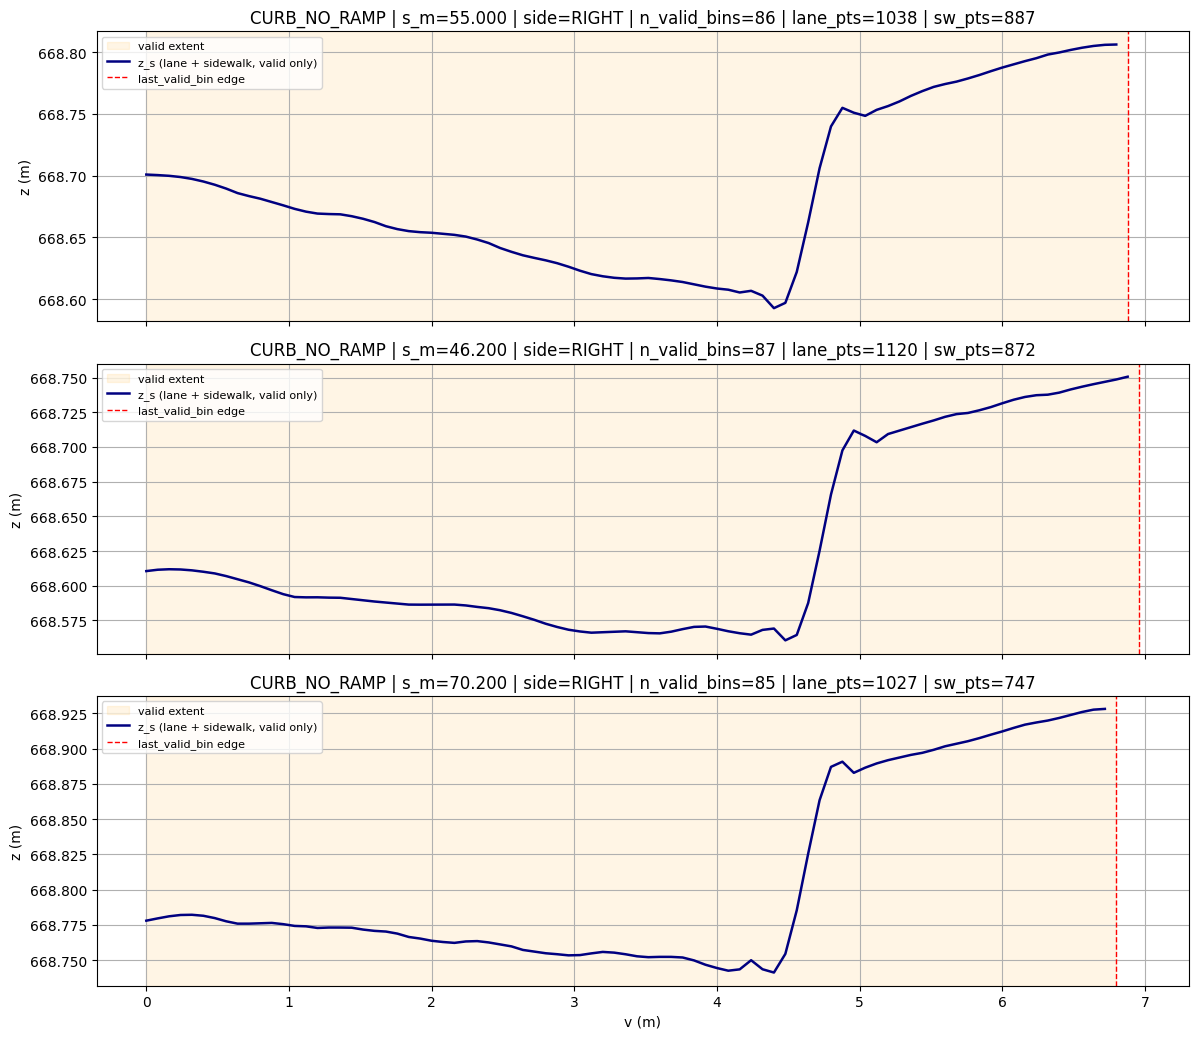

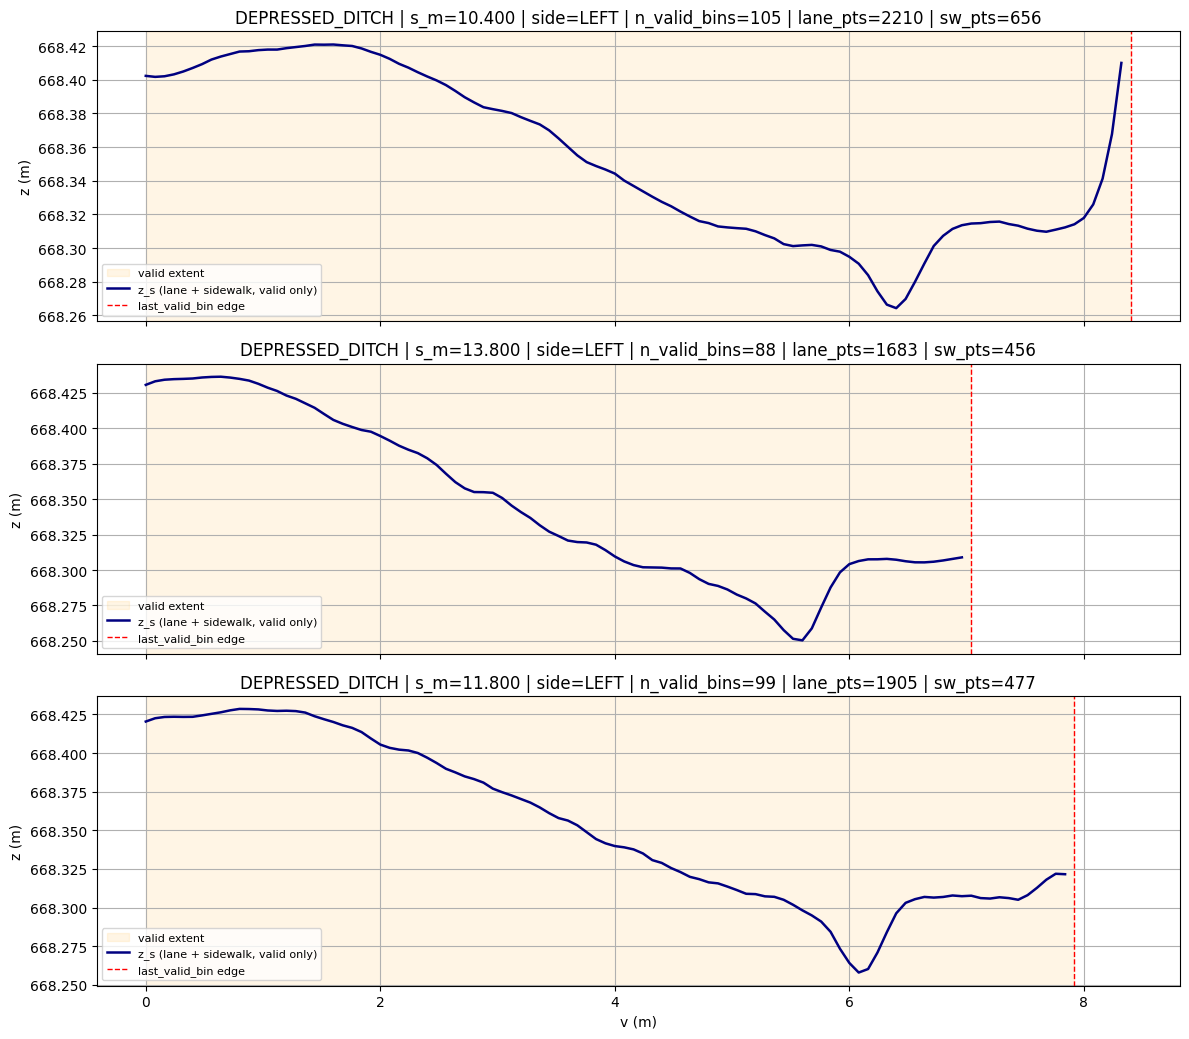

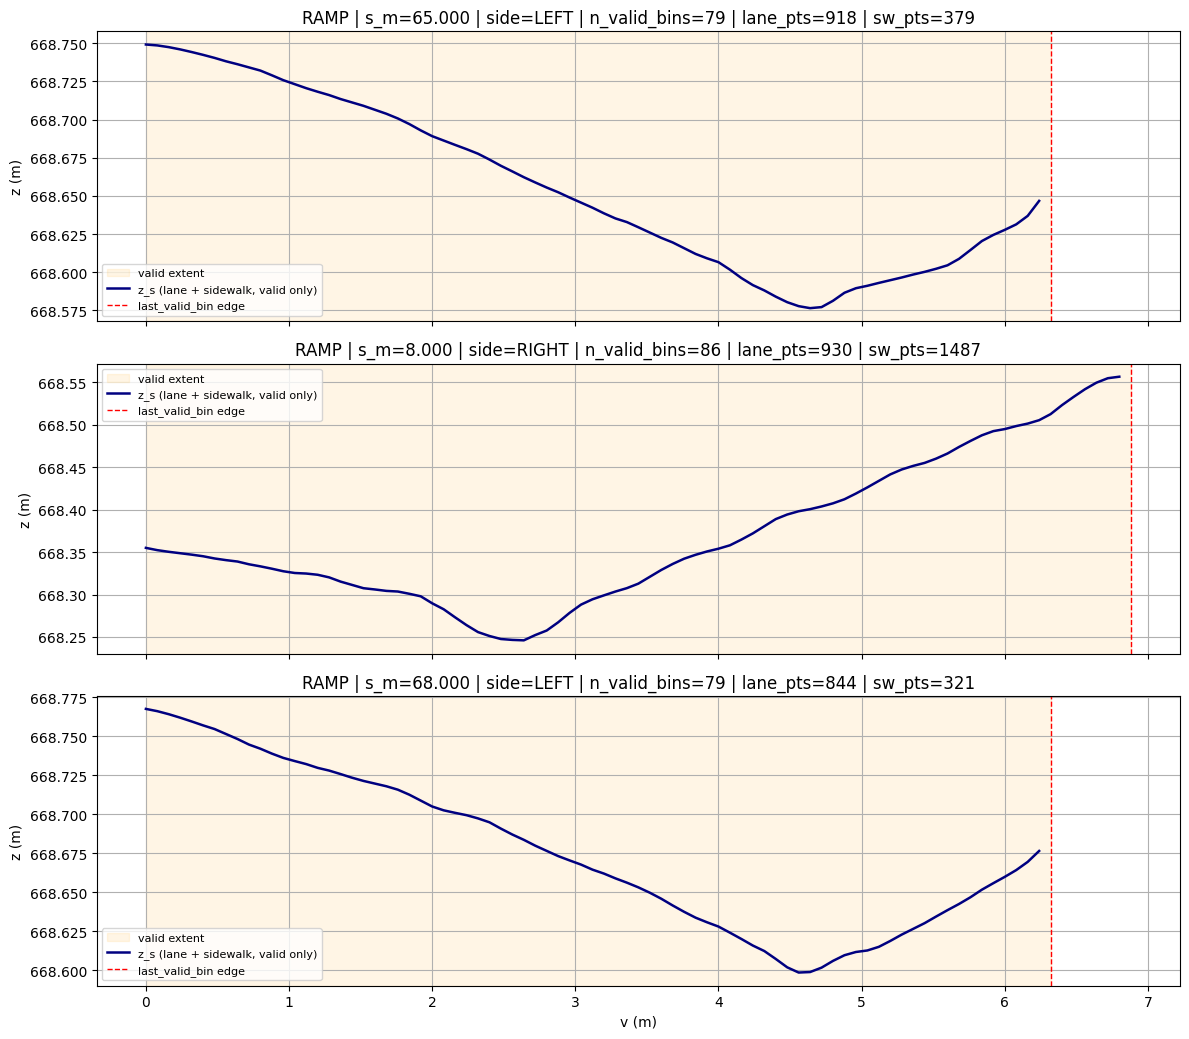

In [8]:
# ============================================================
# CELL 8 - Spot-Check Sample Profiles
# ============================================================
rng = np.random.default_rng(RANDOM_SEED)
v_axis = np.arange(N_BINS) * BIN_SIZE

if df_cnn.empty:
    print("Dataset is empty; nothing to plot.")
else:
    for label in sorted(df_cnn["label"].dropna().unique()):
        subset = df_cnn[df_cnn["label"] == label]
        n_plot = min(PLOT_SAMPLES_PER_CLASS, len(subset))
        if n_plot == 0:
            continue

        chosen_idx = rng.choice(subset.index.to_numpy(), size=n_plot, replace=False)
        fig, axes = plt.subplots(n_plot, 1, figsize=(12, 3.5 * n_plot), sharex=True)
        if n_plot == 1:
            axes = [axes]

        for ax, idx in zip(axes, chosen_idx):
            row = df_cnn.loc[idx]
            z_vals = row[PROFILE_COLS].to_numpy(dtype=float)
            last_valid_bin = int(row["last_valid_bin"])
            n_valid_bins = int(row["n_valid_bins"])
            z_plot = np.full(N_BINS, np.nan, dtype=float)

            if last_valid_bin >= 0:
                valid_end_v = (last_valid_bin + 1) * BIN_SIZE
                z_plot[: last_valid_bin + 1] = z_vals[: last_valid_bin + 1]
                ax.axvspan(0.0, valid_end_v, color="orange", alpha=0.10, label="valid extent")
                ax.plot(v_axis, z_plot, lw=1.8, c="navy", label="z_s (lane + sidewalk, valid only)")
                ax.axvline(valid_end_v, color="red", ls="--", lw=1, label="last_valid_bin edge")
            else:
                ax.plot(v_axis, z_plot, lw=1.8, c="navy", label="z_s")

            ax.set_title(f"{label} | s_m={row['s_m']:.3f} | side={row['side']} | n_valid_bins={n_valid_bins} | lane_pts={int(row['n_lane_pts'])} | sw_pts={int(row['n_sidewalk_pts'])}")
            ax.set_ylabel("z (m)")
            ax.grid(True)
            ax.legend(fontsize=8)

        axes[-1].set_xlabel("v (m)")
        plt.tight_layout()
        plt.show()
